In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import re
import os
import string
import datetime
from datetime import datetime, timedelta

In [2]:
import platform
from matplotlib import rcParams

system = platform.system()

if system == "Windows":
    rcParams["font.family"] = "Meiryo"
elif system == "Darwin":  # macOS
    rcParams["font.family"] = "Hiragino Sans"
else:  # Linux
    rcParams["font.family"] = "IPAexGothic"

rcParams["font.size"] = 12

## original data

In [3]:
ORIGINAL_FILE_PATH = "Data/original_data/SampleX_MethodA_20991231.CSV"
ORIGINAL_TREND_FILE_PATH = "Data/original_data/Trend_SampleX_MethodA_20991231.csv"

original = pd.read_csv(ORIGINAL_FILE_PATH, encoding='shift_jis', names=range(15))
trend_template = pd.read_csv(ORIGINAL_TREND_FILE_PATH, header=1, usecols=range(0, 31), encoding="shift_jis")

## データ作成用関数

In [4]:
# ユーザーごとの前処理条件の傾向（アーキタイプ）。
# 測定者ごとに一貫したストーリー（例: 高温・多パルス志向 / 低温・少パルスで手早く済ませる）を
# 持たせるため、ガス・時間・流量・目標温度・最大パルス回数をまとめて1ユーザーに1つ割り当てる。
ARCHETYPES = {
    "baseline": dict(
        gas=(["Gas X"], [1.0]),
        time=(["30", "40", "50", "100"], [0.80, 0.10, 0.07, 0.03]),
        flowrate=dict(center=50, min_abs=10, max_abs=30),
        temp_multiplier=np.array([1, 1, 1, 1, 1, 1]),
        max_pulse=([12, 16, 20, 30, 40], [0.10, 0.70, 0.15, 0.03, 0.02]),
    ),
    "thorough_hightemp": dict(
        gas=(["Gas X"], [1.0]),
        time=(["40", "50", "100"], [0.45, 0.35, 0.20]),
        flowrate=dict(center=45, min_abs=10, max_abs=20),
        temp_multiplier=np.array([0.2, 0.5, 1.0, 1.3, 1.4, 1.3]),
        max_pulse=([20, 30, 40], [0.30, 0.45, 0.25]),
    ),
    "quick_lowtemp": dict(
        gas=(["Gas X"], [1.0]),
        time=(["30", "40"], [0.92, 0.08]),
        flowrate=dict(center=35, min_abs=5, max_abs=15),
        temp_multiplier=np.array([1.6, 1.3, 0.3, 0.1, 0.05, 0.05]),
        max_pulse=([12, 16], [0.65, 0.35]),
    ),
    "high_throughput": dict(
        gas=(["Gas X"], [1.0]),
        time=(["30", "40"], [0.95, 0.05]),
        flowrate=dict(center=70, min_abs=5, max_abs=15),
        temp_multiplier=np.array([1.0, 1.3, 1.1, 0.7, 0.4, 0.2]),
        max_pulse=([16, 20], [0.55, 0.45]),
    ),
    "signature_gas_y": dict(
        gas=(["Gas Y", "Gas X"], [0.90, 0.10]),
        time=(["30", "40", "50"], [0.75, 0.15, 0.10]),
        flowrate=dict(center=55, min_abs=10, max_abs=20),
        temp_multiplier=np.array([1, 1, 1, 1, 1, 1]),
        max_pulse=([12, 16, 20], [0.15, 0.70, 0.15]),
    ),
    "signature_gas_z": dict(
        gas=(["Gas Z", "Gas X"], [0.92, 0.08]),
        time=(["30", "40"], [0.85, 0.15]),
        flowrate=dict(center=55, min_abs=10, max_abs=20),
        temp_multiplier=np.array([1, 1, 1, 1, 1, 1]),
        max_pulse=([12, 16, 20], [0.10, 0.75, 0.15]),
    ),
}

USER_TO_ARCHETYPE = {
    "UserA": "baseline", "UserB": "baseline", "UserH": "baseline",
    "UserI": "baseline", "UserM": "baseline",
    "UserD": "thorough_hightemp", "UserJ": "thorough_hightemp", "UserL": "thorough_hightemp",
    "UserE": "quick_lowtemp", "UserK": "quick_lowtemp", "UserO": "quick_lowtemp",
    "UserF": "high_throughput", "UserG": "high_throughput",
    "UserC": "signature_gas_y",
    "UserN": "signature_gas_z",
}

GAS_DISTRIBUTION = {u: ARCHETYPES[a]["gas"] for u, a in USER_TO_ARCHETYPE.items()}
TIME_DISTRIBUTION = {u: ARCHETYPES[a]["time"] for u, a in USER_TO_ARCHETYPE.items()}
MAX_PULSE_DISTRIBUTION = {u: ARCHETYPES[a]["max_pulse"] for u, a in USER_TO_ARCHETYPE.items()}
FLOWRATE_PROFILE = {u: ARCHETYPES[a]["flowrate"] for u, a in USER_TO_ARCHETYPE.items()}
TEMP_MULTIPLIER = {u: ARCHETYPES[a]["temp_multiplier"] for u, a in USER_TO_ARCHETYPE.items()}

DEFAULT_FLOWRATE = dict(center=50, min_abs=10, max_abs=30)
DEFAULT_MAX_PULSE = ([12, 16, 20, 30, 40], [0.10, 0.70, 0.15, 0.03, 0.02])

# 前処理設定温度の中心値（実機の設定可能範囲は最大1000℃）
TOP_TEMPERATURE_CENTERS = ["200", "300", "400", "500", "600", "700"]

# STEP1, 5, 6の目標温度のベース値（元データのSTEP1=150, STEP5=25, STEP6=25を
# 定数化したもの。既存の生成パターンを変えないよう、元データと同じ値を使う）
PRETREATMENT_BASE_TARGET_TEMPERATURE = {28: 150, 32: 25, 33: 25}

# STEP1, 2, 4, 6の時間のベース値（元データのSTEP1=30, STEP2=60, STEP4=20, STEP6=10を
# 定数化したもの。既存の生成パターンを変えないよう、元データと同じ値を使う）
PRETREATMENT_BASE_TIME = {28: 30, 29: 60, 31: 20, 33: 10}

# 200℃・300℃の重みは固定（300℃が常に最頻値）。400〜700℃の重みだけが
# 測定年(start_year〜end_year)を経るごとに0から徐々に増えていく
_BASE_TEMP_WEIGHTS = np.array([0.15, 0.50, 0.0, 0.0, 0.0, 0.0])       # 200,300,400,500,600,700（t=0時点）
_GROWTH_TEMP_WEIGHTS = np.array([0.0, 0.0, 0.15, 0.10, 0.06, 0.04])   # 400〜700が伸びる分（t=1で加算完了）


def top_temperature_weights(measurement_date, username=None, start_year=2020, end_year=2030):
    """measurement_dateの年に応じて、300℃を常に最頻値としたまま、
    400℃以上の重みだけを徐々に増やしていく（組織全体の年次トレンド）。
    そこにusernameのアーキタイプごとのtemp_multiplierを掛けて、
    年次トレンドを保ったままユーザーごとに高温/低温寄りへ傾ける。"""
    t = (measurement_date.year - start_year) / (end_year - start_year)
    t = min(max(t, 0.0), 1.0)
    weights = _BASE_TEMP_WEIGHTS + t * _GROWTH_TEMP_WEIGHTS
    weights = weights * TEMP_MULTIPLIER.get(username, np.ones(6))
    return weights / weights.sum()


def weighted_choice(rng, distribution, username, default):
    """usernameに対応する分布があればrng.choiceで抽選し、なければdefaultをそのまま返す。"""
    if username in distribution:
        choices, probabilities = distribution[username]
        return rng.choice(choices, p=probabilities)
    return default


def broaden_temperature(rng, center_str, spread=20.0, min_temp=100.0, max_temp=1000.0, round_to=10):
    """centerを中心に正規分布でばらつかせ、[min_temp, max_temp]にクリップし、round_to単位に丸める。"""
    center = float(center_str)
    value = rng.normal(center, spread)
    value = min(max(value, min_temp), max_temp)
    value = round(value / round_to) * round_to
    return str(int(value))

In [5]:
def random_rate(rng):
    if rng.choice([True, False]):
        value = round(rng.uniform(0.6, 0.9), 2)
    else:
        value = round(rng.uniform(1.2, 1.4), 2)
    
    return value

def random_plus_or_minus(rng, min_abs=10, max_abs=30):
    if rng.choice([True, False]):
        value = int(rng.choice(range(min_abs, max_abs + 5, 5)))
    else:
        value = int(rng.choice(range(-min_abs, -max_abs - 5, -5)))
    
    return value

def _to_str_preserving_nan(arr):
    """
    floatのnumpy配列を文字列化する。pandas Series.astype(str)と同様、NaNは
    文字列"nan"にせずNaNのまま保持する（numpy標準のastype(str)はNaNをそのまま
    文字列化してしまうため、その差異を吸収する）。
    """
    out = np.empty(arr.shape, dtype=object)
    mask = np.isnan(arr)
    out[mask] = np.nan
    out[~mask] = arr[~mask].astype(str)
    return out

def flat_curve(rng, n, base, noise):
    """ほぼ横ばいのカーブ: base ± noise の一様乱数"""
    return base + rng.uniform(-noise, noise, size=n)

def saturating_curve(rng, n, base, amplitude, k_range):
    """パルスを重ねるごとに base + amplitude に近づいていく飽和カーブ"""
    k = rng.uniform(*k_range)
    i = np.arange(n)
    return base + amplitude * (1 - np.exp(-k * i))

def decaying_curve(rng, n, start, k_range):
    """パルスを重ねるごとに0に近づいていく減衰カーブ"""
    k = rng.uniform(*k_range)
    i = np.arange(n)
    return start * np.exp(-k * i)

# 測定値A2〜A14: 元データ（original_file_path / template_df）は参照せず、
# 列ごとに割り当てた形状・パラメータから直接カーブを生成する
PULSE_COLUMN_GENERATORS = {
    2:  (flat_curve,       dict(base=140.0, noise=2.0)),
    3:  (flat_curve,       dict(base=6.0,   noise=0.1)),
    4:  (flat_curve,       dict(base=2.4,   noise=0.05)),
    5:  (saturating_curve, dict(base=0.0,   amplitude=-450.0,   k_range=(0.15, 0.35))),
    6:  (saturating_curve, dict(base=0.0,   amplitude=-18000.0, k_range=(0.15, 0.35))),
    7:  (saturating_curve, dict(base=0.0,   amplitude=9.5,      k_range=(0.15, 0.35))),
    8:  (decaying_curve,   dict(start=620.0, k_range=(0.15, 0.35))),
    9:  (saturating_curve, dict(base=110.0, amplitude=95.0,  k_range=(0.1, 0.3))),
    10: (flat_curve,       dict(base=-4.5,  noise=0.4)),
    11: (saturating_curve, dict(base=48.0,  amplitude=36.0, k_range=(0.1, 0.3))),
    12: (saturating_curve, dict(base=0.0,   amplitude=-26.0, k_range=(0.1, 0.3))),
    13: (saturating_curve, dict(base=78.0,  amplitude=52.0, k_range=(0.1, 0.3))),
    14: (flat_curve,       dict(base=-2.2,  noise=0.3)),
}

# 測定結果1, 2, 4〜8: 元データは参照せず、項目ごとに割り当てたレンジから生成する
# （測定結果3＝測定値A8合計は、上で生成した測定値A8カーブから都度計算するため対象外）
RESULT_VALUE_RANGES = {
    97:  (150.0, 20.0),   # 測定結果1
    98:  (0.8,   0.05),   # 測定結果2
    100: (4.5,   0.3),    # 測定結果4
    101: (1.2,   0.1),    # 測定結果5
    102: (3.5,   0.2),    # 測定結果6
    103: (95.0,  8.0),    # 測定結果7
    104: (18.0,  1.5),    # 測定結果8
}

def generate_dummy(rng, original_file_path, created_file_path, created_at, template_df=None):
    username = next(part for part in Path(created_file_path).parts if part.startswith("User"))
    df = template_df.copy() if template_df is not None else pd.read_csv(original_file_path, encoding='shift_jis', names=range(15))
    # DataFrame.ilocへの1セルずつの代入は遅いため、numpy配列に変換してから
    # 書き換え、最後にDataFrameへ戻す
    columns = df.columns
    arr = df.to_numpy(copy=True)

    # B6 ~ B8
    arr[5, 1] = "分析装置"
    arr[6, 1] = "X9999"
    arr[7, 1] = "1234"

    # C15 ~ C21
    arr[14, 2] = created_file_path
    arr[15, 2] = Path(created_file_path).stem

    # コメントは削除
    for i in range(16, 20):
        arr[i, 2] = ""
    
    # サンプル重量
    arr[20, 2] = "1.0"

    # 日時の入れ替え
    date_replacements = {
        "2100-04-01": created_at.strftime("%Y-%m-%d"),
        "08:00:00": "10:00:00",
        "10:00:00": "12:00:00",
        "10:30:00": "12:30:00",
        "12:30:00": "14:30:00",
    }
    for i in [24, 25, 74, 75]:
        for old, new in date_replacements.items():
            arr[i, 2] = arr[i, 2].replace(old, new)
    
    # 設定パラメータの入れ替え
    # 設定パラメータの入れ替え: タイトル
    new_pretreatment_labels = ["ガス", "流量", "時間", "温度", "X機構"]
    for i, colnum in enumerate(range(2, 7)):
        arr[27, colnum] = new_pretreatment_labels[i]

    # B38 ~ B71
    for i, row in enumerate(range(37, 71)):
        arr[row, 1] = f"設定値{i}"
    
    # 設定値
    arr[61, 2] = "30" # 設定値24
    arr[62, 2] = "60" # 設定値25
    arr[65, 2] = "10" # 設定値28
    arr[66, 2] = "20" # 設定値29
    
    # "パルス数"
    arr[79, 1] = "パルス数"
    
    # 設定パラメータの入れ替え: 数値
    flowrate_profile = FLOWRATE_PROFILE.get(username, DEFAULT_FLOWRATE)
    new_flowrate = str(flowrate_profile["center"] + random_plus_or_minus(
        rng, flowrate_profile["min_abs"], flowrate_profile["max_abs"]))
    weights = top_temperature_weights(created_at, username)
    new_top_temperature = broaden_temperature(rng, rng.choice(TOP_TEMPERATURE_CENTERS, p=weights))

    for i, cellnum in enumerate(range(28, 34)):
        # ガス名
        arr[cellnum, 2] = weighted_choice(rng, GAS_DISTRIBUTION, username, "Gas X")

        # 流量
        arr[cellnum, 3] = new_flowrate

        # 時間
        if cellnum == 30:
            arr[cellnum, 4] = weighted_choice(rng, TIME_DISTRIBUTION, username, "30")
        elif cellnum == 32:
            arr[cellnum, 4] = str("1")
        else:
            base_time = PRETREATMENT_BASE_TIME[cellnum]
            arr[cellnum, 4] = str(base_time + rng.choice(range(0, 20 + 5, 5)))

        # 目標温度
        if cellnum in [29, 30, 31]:
            arr[cellnum, 5] = new_top_temperature
        else:
            base_top_temperature = PRETREATMENT_BASE_TARGET_TEMPERATURE[cellnum]
            arr[cellnum, 5] = str(base_top_temperature + random_plus_or_minus(rng, max_abs=20))

    # 最大パルス回数（設定）
    max_pulse_choices, max_pulse_probs = MAX_PULSE_DISTRIBUTION.get(username, DEFAULT_MAX_PULSE)
    max_pulse = rng.choice(max_pulse_choices, p=max_pulse_probs)
    arr[68, 2] = str(max_pulse)

    # 実際のパルス回数
    actual_pulse_number = min(max_pulse, 16)
    arr[79, 2] = str(actual_pulse_number)
    
    # パルスデータの置き換え
    for i in range(1, 15):
        arr[80, i] = f"測定値A{i}"
    
    # 測定値A2〜A14
    # 元データは参照せず、列ごとに割り当てた形状パラメータ（PULSE_COLUMN_GENERATORS）から生成する
    n_pulses = arr[81:98, 1].shape[0]
    for col, (curve_func, params) in PULSE_COLUMN_GENERATORS.items():
        arr[81:98, col] = _to_str_preserving_nan(curve_func(rng, n_pulses, **params).round(4))

    # パルス数が16未満であればパルス数以上の測定値A8を0に
    exceed_pulse = 16 - max_pulse
    if exceed_pulse > 0:
        arr[(97 - exceed_pulse):97, 8] = "0"    

    # 結果のデータの書き換え
    for i, cellnum in enumerate(range(97, 105)):
        arr[cellnum, 1] = f"測定結果{i + 1}"

        # 測定値A8合計のセルは"測定値A8"の合計（max_puluse分の合計）を表示する
        if cellnum == 99:
            last_pulse_row = 81 + max_pulse
            total_a8 = round(np.nansum(arr[81:last_pulse_row, 8].astype(float)), 4)
            arr[cellnum, 2] = str(total_a8)
        else:
            base, noise = RESULT_VALUE_RANGES[cellnum]
            arr[cellnum, 2] = str(round(base + rng.uniform(-noise, noise), 3))
    
    # グラフデータ書き換え
    # 測定値B1(sec)・測定値B2(μV・sec)は元データを参照せず、行数分を新規生成する
    for i in range(1, 3):
        arr[108, i] = f"測定値B{i}"

    n_graph_points = arr[109:, 1].shape[0]
    arr[109:, 1] = np.arange(1, n_graph_points + 1)
    arr[109:, 2] = _to_str_preserving_nan(rng.normal(0, 5, size=n_graph_points).round(1))
    
    return pd.DataFrame(arr, columns=columns)

In [6]:
def generate_temperature_trend(total_points, room_temp, steps, cooling_tau, rng, noise_std=0.3):
    """
    ステップ（複数段階）→ 自然放熱、の温度トレンドを1秒間隔で生成する。

    各ステップは「目標温度XX℃をYY分維持する」設定であり、実際の温度変化は
    直前の温度との大小関係で決まる：
      - 目標温度 > 現在温度：加熱（直線的に目標温度まで上昇）
      - 目標温度 < 現在温度：自然放熱（ニュートンの冷却則で目標温度へ指数関数的に漸近。
        時間内に必ずしも目標温度へ到達するとは限らない）
      - 目標温度 == 現在温度：その温度を維持

    Parameters
    ----------
    total_points : int
        生成するデータ点数（1点=1秒間隔を想定）
    room_temp : float
        室温 (℃)。全ステップ終了後の自然放熱が収束する温度でもある。
    steps : list[tuple[float, float]]
        (target_temp, duration) のリスト。durationは秒。
    cooling_tau : float
        自然放熱（ニュートンの冷却則）の時定数 (秒)。ステップ途中の降温にも、
        全ステップ終了後の放熱にも同じ時定数を使う。
    rng : np.random.Generator
        測定ノイズ生成用の乱数生成器
    noise_std : float
        測定ノイズの標準偏差
    """
    time_arr = np.arange(total_points)
    temperature = np.empty(total_points, dtype=float)

    t_prev, temp_prev = 0.0, room_temp
    for target_temp, duration in steps:
        t_next = t_prev + duration
        mask = (time_arr >= t_prev) & (time_arr < t_next)
        elapsed = time_arr[mask] - t_prev

        if target_temp > temp_prev:
            # 加熱：durationかけて目標温度まで直線的に上昇
            temperature[mask] = temp_prev + (target_temp - temp_prev) * (elapsed / duration)
            end_temp = target_temp
        elif target_temp < temp_prev:
            # 自然放熱：ニュートンの冷却則で目標温度へ指数関数的に近づく
            temperature[mask] = target_temp + (temp_prev - target_temp) * np.exp(-elapsed / cooling_tau)
            end_temp = target_temp + (temp_prev - target_temp) * np.exp(-duration / cooling_tau)
        else:
            # 同じ温度を維持
            temperature[mask] = temp_prev
            end_temp = temp_prev

        t_prev, temp_prev = t_next, end_temp

    # 全ステップ終了後も自然放熱を継続し、室温へ指数関数的に漸近
    mask_cooling = time_arr >= t_prev
    temperature[mask_cooling] = room_temp + (temp_prev - room_temp) * np.exp(
        -(time_arr[mask_cooling] - t_prev) / cooling_tau
    )

    return temperature + rng.normal(0, noise_std, size=total_points)


def _temperature_after_steps(room_temp, steps, cooling_tau):
    """generate_temperature_trend()と同じ規則で、steps適用後の到達温度だけを計算する。"""
    temp_prev = room_temp
    for target_temp, duration in steps:
        if target_temp > temp_prev:
            temp_prev = target_temp
        elif target_temp < temp_prev:
            temp_prev = target_temp + (temp_prev - target_temp) * np.exp(-duration / cooling_tau)
        # 同じ温度なら変化なし
    return temp_prev


def _duration_to_reach(start_temp, stop_at_temp, room_temp, cooling_tau):
    """
    自然放熱（room_tempへ指数関数的に収束）でstart_tempからstop_at_tempまで
    下がるのに掛かる時間を解析的に計算する（start_temp > stop_at_temp > room_tempを想定）。
    """
    ratio = (stop_at_temp - room_temp) / (start_temp - room_temp)
    return max(-cooling_tau * np.log(ratio), 0.0)


# 1日分（0〜86399秒）の"HH:MM:SS"文字列を一度だけ作っておき、TIME列生成を高速化する
_TIME_OF_DAY_LOOKUP = np.array([
    f"{s // 3600:02d}:{(s % 3600) // 60:02d}:{s % 60:02d}" for s in range(86400)
])


def _heater_hold_stats(machine, measurement_date):
    """一定温度維持区間におけるヒーター温度が前処理設定温度に対してどれだけ比例して
    高くなるか(比例係数, 標準偏差)を装置・測定時期から決める。"""
    if machine == "MachineA":
        return 0.05, 1.0
    if measurement_date < datetime(2025, 1, 1):
        return 0.05, 1.0
    return 0.15, 1.0


def _measured_hold_stats(machine):
    """一定温度維持区間における測定部温度の(ヒーター温度からのオフセット, 標準偏差)を装置から決める。"""
    if machine == "MachineA":
        return -20.0, 10.0
    return -10.0, 5.0


# 測定部センサーの接触不良などを想定し、まれにヒーター温度との差が100℃を超える異常値を発生させる確率
HUGE_TEMPDIFF_PROBABILITY = 0.02

# calculate_constant_temp_average()のmin_temp(=90℃)と同じ値。異常値がこれを下回ると
# 一定温度区間として検出されずNaNになり、分析側で異常値として拾えなくなってしまう
MIN_HOLD_TEMP = 90.0


def _measured_hold_temp(heater_hold_temp, machine, rng):
    """一定温度維持区間における測定部温度を、ヒーター温度・装置から決める。
    ヒーター温度がMIN_HOLD_TEMPより十分高い場合に限り、HUGE_TEMPDIFF_PROBABILITYの確率で、
    センサー接触不良を想定し、ヒーター温度との差が100℃を超える異常値を発生させる
    （MIN_HOLD_TEMPを下回ると一定温度区間として検出されずNaNになってしまうため）。

    Returns
    -------
    tuple[float, bool]
        (測定部温度, 異常値かどうか)。異常値の場合、接触不良という性質上、自然放熱のような
        緩やかな変化ではなく即座に生じるべきものなので、呼び出し側（generate_trend_dummy）で
        該当区間の測定部温度をこの値でフラットに上書きする必要がある。
    """
    if heater_hold_temp >= MIN_HOLD_TEMP + 200.0 and rng.random() < HUGE_TEMPDIFF_PROBABILITY:
        max_diff = min(150.0, heater_hold_temp - MIN_HOLD_TEMP - 1.0)
        return heater_hold_temp - rng.uniform(100.0, max_diff), True
    measured_offset, measured_std = _measured_hold_stats(machine)
    return heater_hold_temp + measured_offset + rng.normal(0, measured_std), False


def generate_trend_dummy(rng, template_trend_df, df, machine, measurement_date, cooling_tau=1100.0,
                          room_temp=25.0, final_settle_offset=0.4, start_time="12:00:00"):
    """
    generate_dummy()が設定した前処理STEP1〜6（df.iloc[28:34]）の温度・時間をもとに、
    Trendデータの"ヒーター温度"・"測定部温度"を加熱・保持・自然放熱のトレンドで生成する。
    STEP1〜6の後、室温付近（room_temp + final_settle_offset）まで自然放熱してから終える
    ステップを追加するため、トレンド全体の長さ（行数）はこれが実際に掛かる時間から動的に
    決まり、テンプレート（template_trend_df）の行数とは一致しない。そのためtemplate_trend_df
    は列名・列順の参照にのみ使い、他の列（信号強度・Value1〜26・TIME）は
    伸びた長さぶんダミー値で新規に埋める。

    "ヒーター温度": STEP1〜6の目標温度をそのままリンクさせる。ただし目標温度がtop_temperature
                 （=new_top_temperature、STEP2の目標温度）と一致する区間は、
                 _heater_hold_stats()が返す装置（machine）・測定時期（measurement_date）
                 ごとの比例係数・標準偏差から、1ファイルにつき1回だけサンプリングした
                 温度に置き換える（同じファイル内では従来通りその温度のまま一定を維持する）。
    "測定部温度": ヒーター温度に温められて温度が決まるため、目標温度がtop_temperatureと一致する
                 区間は、上記でサンプリングしたヒーター温度を基準に_measured_hold_temp()が返す
                 装置ごとのオフセット・標準偏差から、同じく1ファイルにつき1回だけサンプリング
                 した温度に置き換える。ただしHUGE_TEMPDIFF_PROBABILITYの確率で、センサー
                 接触不良を想定し、前処理の昇温・保持・放熱すべての段階でヒーター温度より
                 大きく低い温度（差が100℃超）で推移する異常値に置き換える
                 （room_tempを下回らないようクリップする）。
    """
    top_temperature = float(df.iloc[29, 5])  # STEP2の目標温度（=new_top_temperature）

    # 一定温度維持区間の温度を、装置・測定時期ごとの分布から1ファイルにつき1回だけサンプリングする
    heater_slope, heater_std = _heater_hold_stats(machine, measurement_date)
    heater_hold_temp = top_temperature + heater_slope * top_temperature + rng.normal(0, heater_std)

    measured_hold_temp, is_hold_anomaly = _measured_hold_temp(heater_hold_temp, machine, rng)

    pretreatment_steps = [
        (heater_hold_temp if float(df.iloc[cellnum, 5]) == top_temperature else float(df.iloc[cellnum, 5]),
         float(df.iloc[cellnum, 4]) * 60)  # (目標温度[℃], 時間[分]→[秒])
        for cellnum in range(28, 34)
    ]
    temp_after_pretreatment = _temperature_after_steps(room_temp, pretreatment_steps, cooling_tau)

    # STEP1〜6の後、室温付近（room_temp + final_settle_offset）まで自然放熱してから終える
    final_settle_temp = room_temp + final_settle_offset
    cool_duration = _duration_to_reach(temp_after_pretreatment, final_settle_temp, room_temp, cooling_tau)

    heater_steps = pretreatment_steps + [(room_temp, cool_duration)]

    if is_hold_anomaly:
        # センサー接触不良を想定し、前処理の昇温・保持・放熱の全段階で、測定部温度が
        # ヒーター温度よりmeasured_offset_anomaly分低い状態で推移する（room_tempを下回らない
        # ようクリップ）。昇温は自然放熱ではなく線形補間なので、指定時間内に必ず目標へ到達する。
        measured_offset_anomaly = measured_hold_temp - heater_hold_temp
        measured_steps = [
            (max(target_temp + measured_offset_anomaly, room_temp), duration)
            for target_temp, duration in heater_steps
        ]
    else:
        measured_steps = [
            (measured_hold_temp if target_temp == heater_hold_temp else target_temp, duration)
            for target_temp, duration in heater_steps
        ]

    total_points = int(np.ceil(sum(duration for _, duration in heater_steps)))

    heater_temp = generate_temperature_trend(total_points, room_temp, heater_steps, cooling_tau, rng)
    measured_temp = generate_temperature_trend(total_points, room_temp, measured_steps, cooling_tau, rng)

    trend_df = pd.DataFrame(index=range(total_points))
    trend_df["SEC"] = np.arange(1, total_points + 1)
    trend_df["測定部温度"] = np.round(measured_temp, 1)
    trend_df["信号強度"] = np.round(rng.normal(100, 10, size=total_points), 1)
    trend_df["ヒーター温度"] = np.round(heater_temp).astype(int)
    for i in range(1, 27):
        trend_df[f"Value{i}"] = 0

    # TIME列：1日分の文字列をあらかじめ用意したlookupテーブルから引くだけにして高速化
    start_h, start_m, start_s = (int(x) for x in start_time.split(":"))
    start_seconds = start_h * 3600 + start_m * 60 + start_s
    time_col = template_trend_df.columns[-1]  # 元の"TIME"列名（末尾の空白込みでそのまま使う）
    trend_df[time_col] = _TIME_OF_DAY_LOOKUP[(start_seconds + np.arange(total_points)) % 86400]

    trend_df = trend_df[template_trend_df.columns]  # 元の列順に揃える

    return trend_df

In [7]:
from datetime import datetime, timedelta
import random

# 2020/01/01から2030/12/31までのランダムな日付をyymmdd形式で出力
def dummy_date(rng):
    start = datetime(2020, 1, 1)
    end = datetime(2030, 12, 31)
    
    days = (end - start).days
    
    random_date = start + timedelta(days=int(rng.integers(0, days)))

    return random_date


def future_dummy_date(rng, base_date=None):
    """
    基準日から1日～365日後の測定日時をランダムに返す。
    日数は7日後をピークとした正規分布に従う。時刻は8:00〜18:59の間でランダムに設定する
    （測定日時としてファイル名に使うため）。
    """
    if base_date is None:
        base_date = datetime.now()

    # 平均7日後、標準偏差30日
    days = round(rng.normal(loc=7, scale=30))

    # 1～365日に制限
    days = max(1, min(days, 365))

    hour = int(rng.integers(8, 19))
    minute = int(rng.integers(0, 60))

    return base_date + timedelta(days=days, hours=hour, minutes=minute)

In [8]:
from pathlib import Path

def get_path_from_user(path: str) -> str:
    """
    UserX以降のパスを取得する。

    例:
    Data/dummy_data/MachineA/UserF/MethodA/sampleD_methodA_261101.csv
    →
    UserF/MethodA/sampleD_methodA_261101.csv
    """
    p = Path(path)
    parts = p.parts

    # "User"で始まるフォルダを探す
    for i, part in enumerate(parts):
        if part.startswith("User"):
            return str(Path(*parts[i:]))

    raise ValueError("Userフォルダが見つかりません。")

## 保存先フォルダのリストを作成

In [9]:
letters = string.ascii_uppercase

users = [f"User{letters[i]}" for i in range(15)]

In [10]:
# 保存先フォルダのパスのリストを作成
targetpaths_MethodA = []
targetpaths_MethodB = []

for which in ["MachineA", "MachineB"]:
    for user in users:
        targetpaths_MethodA.append(f"Data/dummy_data/{which}/{user}/MethodA")

for which in ["MachineA", "MachineB"]:
    for user in users:
        targetpaths_MethodB.append(f"Data/dummy_data/{which}/{user}/MethodB")

## 試験

In [11]:
rng = np.random.default_rng(42)

folder_path = rng.choice(targetpaths_MethodA)
machine_name = Path(folder_path).parts[-3]
sample_prepared_date = dummy_date(rng)
measurement_date = future_dummy_date(rng, sample_prepared_date)

new_sample_name = rng.choice(["sampleA", "sampleB", "sampleC", "sampleD", "sampleE", "sampleF"])
savepath = os.path.join(
    folder_path,
    f"{new_sample_name}_{sample_prepared_date.strftime('%y%m%d')}-MethodA-{measurement_date.strftime('%y%m%d-%H%M')}.csv"
)

created_file_path = f"C:/{machine_name}/DATA/{get_path_from_user(savepath)}"

In [12]:
rng = np.random.default_rng(57)

df = generate_dummy(
    rng,
    ORIGINAL_FILE_PATH, 
    created_file_path=created_file_path,
    created_at=measurement_date,
    template_df=original
)

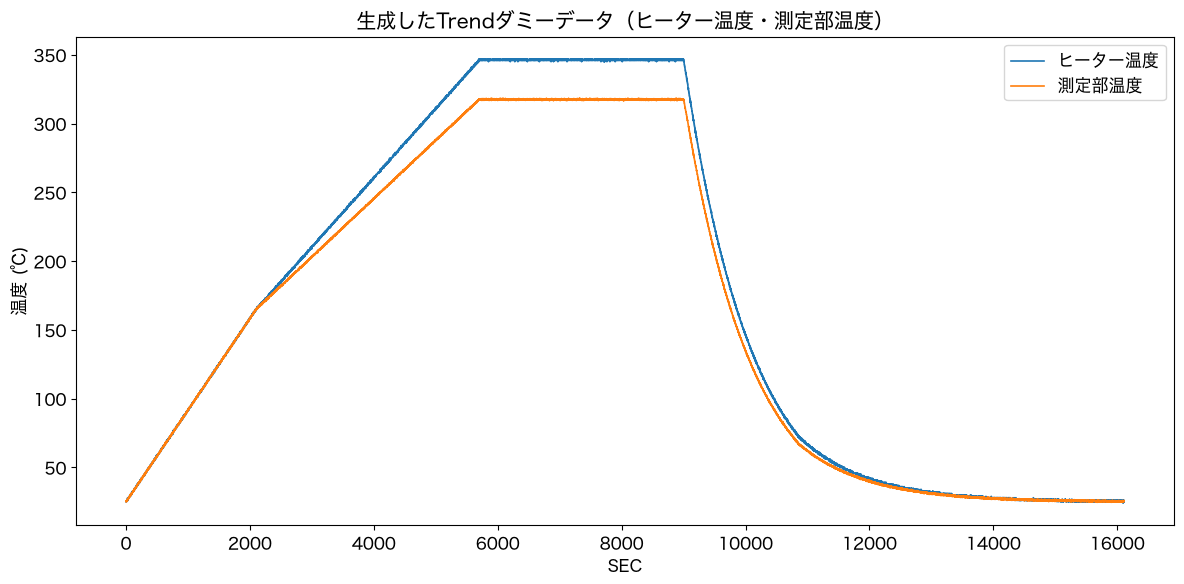

In [13]:
trend_df = generate_trend_dummy(rng, trend_template, df, machine_name, measurement_date)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(trend_df["SEC"], trend_df["ヒーター温度"], label="ヒーター温度", linewidth=1.2)
ax.plot(trend_df["SEC"], trend_df["測定部温度"], label="測定部温度", linewidth=1.2)

ax.set_xlabel("SEC")
ax.set_ylabel("温度 (℃)")
ax.set_title("生成したTrendダミーデータ（ヒーター温度・測定部温度）")
ax.legend()

plt.tight_layout()
plt.show()

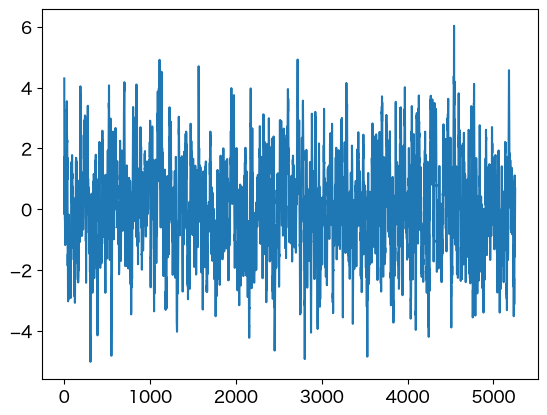

In [14]:
x = df.iloc[109:, 1].astype(float)
y = df.iloc[109:, 2].astype(float)

plt.plot(
    x,
    y.rolling(window=10, min_periods=1).mean()
)
plt.show()

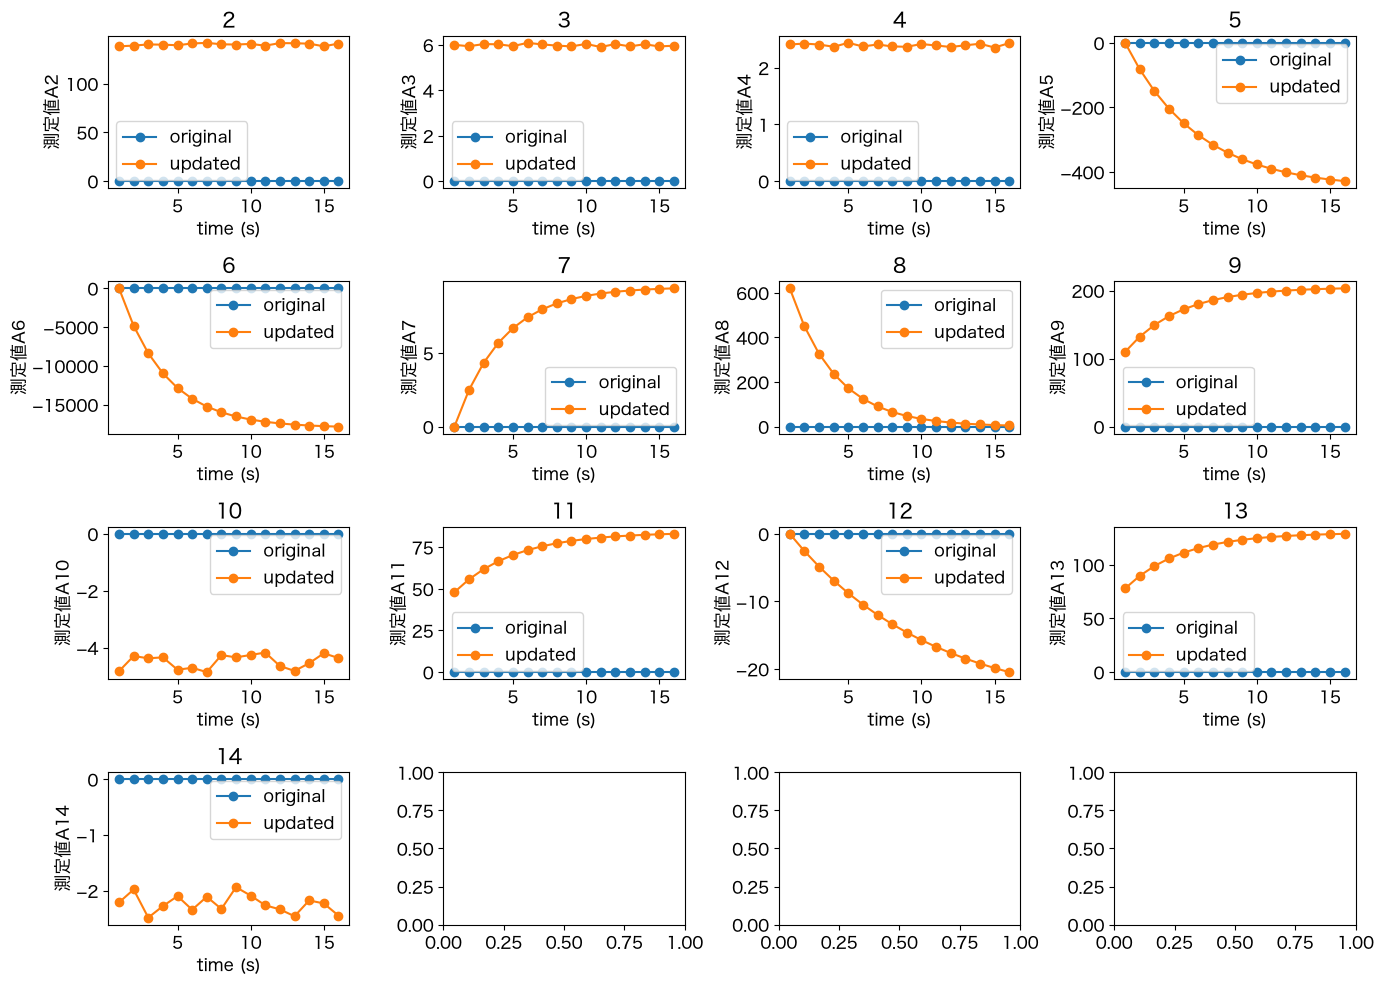

In [15]:
fig, axs = plt.subplots(4, 4, figsize=(14, 10))
axs = axs.ravel()  # 2次元配列を1次元にする

# 81:97, 1:14
for ax, col in zip(axs, np.arange(2, 15)):
    ori_x, ori_y = original.iloc[81:97, 1].astype(float), original.iloc[81:97, col].astype(float)
    updated_x, updated_y = df.iloc[81:97, 1].astype(float), df.iloc[81:97, col].astype(float)
    
    ax.plot(ori_x, ori_y, marker="o", label="original")
    ax.plot(updated_x, updated_y, marker="o", label="updated")
    ax.set_title(col)
    ax.set_xlabel("time (s)")
    ax.set_ylabel(original.iloc[80, col])
    ax.legend()

plt.tight_layout()
plt.show()

## フォルダー作成

In [16]:
# create folder
# Data/dummy_data/{which}/{user}/{method}形式のフォルダーを生成
for which in ["MachineA", "MachineB"]:
    for user in users:
        for method in ["MethodA", "MethodB"]:
            folderpath = f"Data/dummy_data/{which}/{user}/{method}"
            os.makedirs(folderpath, exist_ok=True)

## generate dummy data

In [17]:
# Trend CSVの保存が途中で失敗した状況を想定し、まれにヘッダー行のみでデータ本体を書かない空のファイルにする確率
CORRUPTED_TREND_PROBABILITY = 0.01

# MethodAのダミーデータをランダムに作成
# Trendのデータも同時に作成（TrdGraphデータに相当）
for i in range(1000):
    rng = np.random.default_rng(i)

    new_sample_name = rng.choice(["sampleA", "sampleB", "sampleC", "sampleD", "sampleE", "sampleF"])
    
    sample_prepared_date = dummy_date(rng)
    measurement_date = future_dummy_date(rng, sample_prepared_date)

    folder_path = rng.choice(targetpaths_MethodA)
    machine_name = Path(folder_path).parts[-3]

    savepath = os.path.join(
        folder_path,
        f"{new_sample_name}_{sample_prepared_date.strftime('%y%m%d')}-MethodA-{measurement_date.strftime('%y%m%d-%H%M')}.csv"
    )
    created_file_path = f"C:/{machine_name}/DATA/{get_path_from_user(savepath)}"

    datatype_path = os.path.join(
        folder_path,
        f"Trend_{new_sample_name}_{sample_prepared_date.strftime('%y%m%d')}-MethodA-{measurement_date.strftime('%y%m%d-%H%M')}.csv"
    )

    # メインのCSV（Trendの前処理ステップとリンクさせるため、savepathの存在有無に関わらず生成する）
    generated_df = generate_dummy(
        rng,
        ORIGINAL_FILE_PATH, 
        created_file_path=created_file_path,
        created_at=measurement_date,
        template_df=original
    )

    if not os.path.exists(savepath):
        generated_df.to_csv(savepath, encoding="shift_jis", index=False, header=False)
        print(f'Files saved at "{savepath}"')
    else:
        print(f'File {savepath} already exists.')

    if not os.path.exists(datatype_path):
        # Trend用のダミーデータ（前処理STEP1〜6の温度・時間をリンクさせる）
        datatype_df = generate_trend_dummy(rng, trend_template, generated_df, machine_name, measurement_date)

        # オリジナルと同様、1行目に"Version X.Y.Z"を記述してから2行目以降にカラム名・データを書き込む
        with open(datatype_path, "w", encoding="shift_jis") as f:
            f.write("Version X.Y.Z\n")
        if rng.random() < CORRUPTED_TREND_PROBABILITY:
            # 保存が途中で中断されたケースを想定し、ヘッダー行のみでデータ本体を書かない空のファイルにする
            print(f'Files saved at "{datatype_path}" (corrupted: empty trend data)')
        else:
            datatype_df.to_csv(datatype_path, encoding="shift_jis", index=False, mode="a")
            print(f'Files saved at "{datatype_path}"')
    else:
        print(f'File {datatype_path} already exists.')

Files saved at "Data/dummy_data/MachineA/UserC/MethodA/sampleF_270102-MethodA-270105-1102.csv"
Files saved at "Data/dummy_data/MachineA/UserC/MethodA/Trend_sampleF_270102-MethodA-270105-1102.csv"
Files saved at "Data/dummy_data/MachineB/UserJ/MethodA/sampleC_250817-MethodA-250918-0808.csv"
Files saved at "Data/dummy_data/MachineB/UserJ/MethodA/Trend_sampleC_250817-MethodA-250918-0808.csv"
Files saved at "Data/dummy_data/MachineA/UserN/MethodA/sampleF_221116-MethodA-221117-1248.csv"


Files saved at "Data/dummy_data/MachineA/UserN/MethodA/Trend_sampleF_221116-MethodA-221117-1248.csv"
Files saved at "Data/dummy_data/MachineB/UserL/MethodA/sampleE_201210-MethodA-201211-0948.csv"
Files saved at "Data/dummy_data/MachineB/UserL/MethodA/Trend_sampleE_201210-MethodA-201211-0948.csv"
Files saved at "Data/dummy_data/MachineB/UserO/MethodA/sampleE_300516-MethodA-300518-1858.csv"
Files saved at "Data/dummy_data/MachineB/UserO/MethodA/Trend_sampleE_300516-MethodA-300518-1858.csv"
Files saved at "Data/dummy_data/MachineB/UserD/MethodA/sampleE_281107-MethodA-281108-1330.csv"


Files saved at "Data/dummy_data/MachineB/UserD/MethodA/Trend_sampleE_281107-MethodA-281108-1330.csv"
Files saved at "Data/dummy_data/MachineB/UserE/MethodA/sampleC_251201-MethodA-260130-1822.csv"
Files saved at "Data/dummy_data/MachineB/UserE/MethodA/Trend_sampleC_251201-MethodA-260130-1822.csv"
Files saved at "Data/dummy_data/MachineB/UserK/MethodA/sampleF_261116-MethodA-261202-1446.csv"
Files saved at "Data/dummy_data/MachineB/UserK/MethodA/Trend_sampleF_261116-MethodA-261202-1446.csv"
Files saved at "Data/dummy_data/MachineB/UserE/MethodA/sampleE_230806-MethodA-230807-0919.csv"


Files saved at "Data/dummy_data/MachineB/UserE/MethodA/Trend_sampleE_230806-MethodA-230807-0919.csv"
Files saved at "Data/dummy_data/MachineB/UserF/MethodA/sampleC_290727-MethodA-290810-0936.csv"
Files saved at "Data/dummy_data/MachineB/UserF/MethodA/Trend_sampleC_290727-MethodA-290810-0936.csv"
Files saved at "Data/dummy_data/MachineB/UserA/MethodA/sampleE_300707-MethodA-300708-1649.csv"
Files saved at "Data/dummy_data/MachineB/UserA/MethodA/Trend_sampleE_300707-MethodA-300708-1649.csv"
Files saved at "Data/dummy_data/MachineB/UserG/MethodA/sampleA_210531-MethodA-210718-1436.csv"


Files saved at "Data/dummy_data/MachineB/UserG/MethodA/Trend_sampleA_210531-MethodA-210718-1436.csv"
Files saved at "Data/dummy_data/MachineA/UserF/MethodA/sampleD_221004-MethodA-221111-0811.csv"
Files saved at "Data/dummy_data/MachineA/UserF/MethodA/Trend_sampleD_221004-MethodA-221111-0811.csv"
Files saved at "Data/dummy_data/MachineB/UserN/MethodA/sampleF_290705-MethodA-290706-0848.csv"
Files saved at "Data/dummy_data/MachineB/UserN/MethodA/Trend_sampleF_290705-MethodA-290706-0848.csv"
Files saved at "Data/dummy_data/MachineA/UserK/MethodA/sampleA_290220-MethodA-290221-0842.csv"


...

Files saved at "Data/dummy_data/MachineB/UserO/MethodA/Trend_sampleC_250908-MethodA-250909-1122.csv"
Files saved at "Data/dummy_data/MachineB/UserF/MethodA/sampleB_220215-MethodA-220307-1734.csv"
Files saved at "Data/dummy_data/MachineB/UserF/MethodA/Trend_sampleB_220215-MethodA-220307-1734.csv"
Files saved at "Data/dummy_data/MachineB/UserE/MethodA/sampleD_220928-MethodA-221008-1615.csv"
Files saved at "Data/dummy_data/MachineB/UserE/MethodA/Trend_sampleD_220928-MethodA-221008-1615.csv"
Files saved at "Data/dummy_data/MachineB/UserO/MethodA/sampleD_200712-MethodA-200729-1033.csv"
Files saved at "Data/dummy_data/MachineB/UserO/MethodA/Trend_sampleD_200712-MethodA-200729-1033.csv" (corrupted: empty trend data)
Files saved at "Data/dummy_data/MachineB/UserJ/MethodA/sampleA_290215-MethodA-290216-0937.csv"


Files saved at "Data/dummy_data/MachineB/UserJ/MethodA/Trend_sampleA_290215-MethodA-290216-0937.csv"
Files saved at "Data/dummy_data/MachineB/UserB/MethodA/sampleA_250622-MethodA-250623-0950.csv"
Files saved at "Data/dummy_data/MachineB/UserB/MethodA/Trend_sampleA_250622-MethodA-250623-0950.csv"
Files saved at "Data/dummy_data/MachineA/UserB/MethodA/sampleE_250618-MethodA-250624-1308.csv"
Files saved at "Data/dummy_data/MachineA/UserB/MethodA/Trend_sampleE_250618-MethodA-250624-1308.csv"
Files saved at "Data/dummy_data/MachineA/UserC/MethodA/sampleF_210422-MethodA-210423-1401.csv"


Files saved at "Data/dummy_data/MachineA/UserC/MethodA/Trend_sampleF_210422-MethodA-210423-1401.csv"
Files saved at "Data/dummy_data/MachineA/UserB/MethodA/sampleD_270904-MethodA-270920-0834.csv"
Files saved at "Data/dummy_data/MachineA/UserB/MethodA/Trend_sampleD_270904-MethodA-270920-0834.csv"
Files saved at "Data/dummy_data/MachineB/UserA/MethodA/sampleA_270114-MethodA-270115-1552.csv"
Files saved at "Data/dummy_data/MachineB/UserA/MethodA/Trend_sampleA_270114-MethodA-270115-1552.csv"
Files saved at "Data/dummy_data/MachineB/UserC/MethodA/sampleD_220211-MethodA-220218-1609.csv"


Files saved at "Data/dummy_data/MachineB/UserC/MethodA/Trend_sampleD_220211-MethodA-220218-1609.csv"
Files saved at "Data/dummy_data/MachineB/UserH/MethodA/sampleF_250205-MethodA-250206-1810.csv"
Files saved at "Data/dummy_data/MachineB/UserH/MethodA/Trend_sampleF_250205-MethodA-250206-1810.csv"
Files saved at "Data/dummy_data/MachineA/UserO/MethodA/sampleE_210113-MethodA-210218-1424.csv"
Files saved at "Data/dummy_data/MachineA/UserO/MethodA/Trend_sampleE_210113-MethodA-210218-1424.csv"
Files saved at "Data/dummy_data/MachineB/UserO/MethodA/sampleE_220106-MethodA-220202-1612.csv"


Files saved at "Data/dummy_data/MachineB/UserO/MethodA/Trend_sampleE_220106-MethodA-220202-1612.csv"
Files saved at "Data/dummy_data/MachineA/UserM/MethodA/sampleE_251229-MethodA-260131-0957.csv"
Files saved at "Data/dummy_data/MachineA/UserM/MethodA/Trend_sampleE_251229-MethodA-260131-0957.csv" (corrupted: empty trend data)
Files saved at "Data/dummy_data/MachineA/UserD/MethodA/sampleE_270912-MethodA-270913-1033.csv"
Files saved at "Data/dummy_data/MachineA/UserD/MethodA/Trend_sampleE_270912-MethodA-270913-1033.csv"
Files saved at "Data/dummy_data/MachineA/UserD/MethodA/sampleE_280725-MethodA-280726-0942.csv"
Files saved at "Data/dummy_data/MachineA/UserD/MethodA/Trend_sampleE_280725-MethodA-280726-0942.csv"
